# POI proximity and price

Do nearby points of interest (metro, schools, parks, hospitals…) actually move the price?
We check distance-to-nearest-POI distributions and the relationship between proximity and price/m².

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('..') / 'datasets' / 'processed' / 'ads_model_v1.csv'
df = pd.read_csv(DATA_PATH)
df['price_per_m2'] = df['target_price_kzt'] / df['area_m2']

POI_CATEGORIES = [
    'metro', 'bus_stops', 'transport',
    'schools', 'kindergartens', 'universities',
    'clinics', 'hospitals', 'polyclinics', 'medcenters',
    'parks', 'supermarkets', 'fitness', 'restaurants_coffee',
]
df.shape

(38762, 128)

## 1. How far is the nearest POI for a typical apartment?

Boxplots of `*_nearest_dist_m` per category, log-scale to fit the long tail of remote listings.

C:\Users\danie\AppData\Local\Temp\ipykernel_34700\2395858031.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


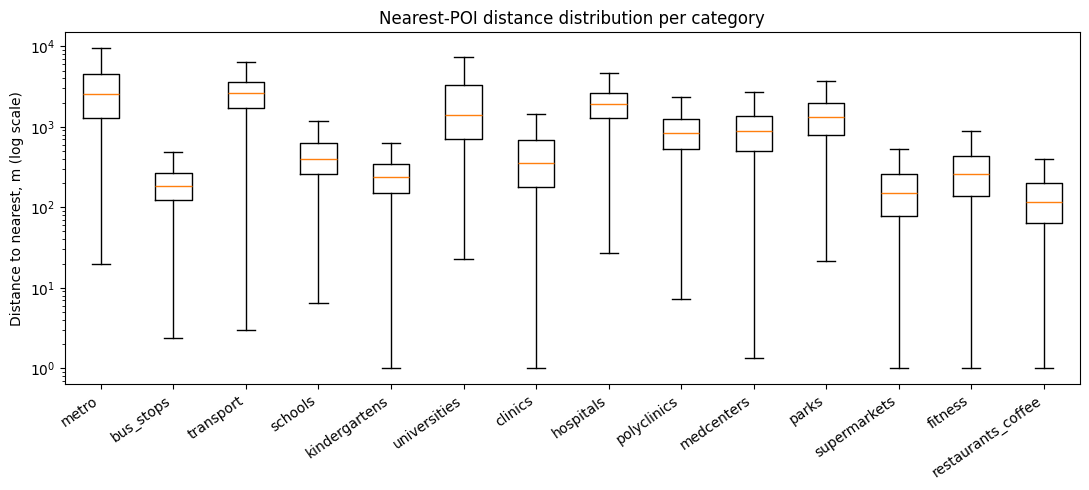

In [2]:
cols = [f'{cat}_nearest_dist_m' for cat in POI_CATEGORIES if f'{cat}_nearest_dist_m' in df.columns]
data = [df[c].dropna().clip(lower=1) for c in cols]
labels = [c.replace('_nearest_dist_m', '') for c in cols]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data, labels=labels, showfliers=False)
ax.set_yscale('log')
ax.set_ylabel('Distance to nearest, m (log scale)')
ax.set_title('Nearest-POI distance distribution per category')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

What this shows: dense everyday-life POIs (bus stops, supermarkets, kindergartens, coffee) sit within a few hundred metres for the median listing. Metro is the outlier — median is several km because there are only a handful of stations. Hospitals and universities also skew far. This explains why `metro_nearest_dist_m` and `universities_nearest_dist_m` carry more signal than dense categories: variance is much larger across the dataset.

## 2. Pearson correlation of distance-to-nearest-POI with price per m²

Negative = closer POIs imply higher prices.

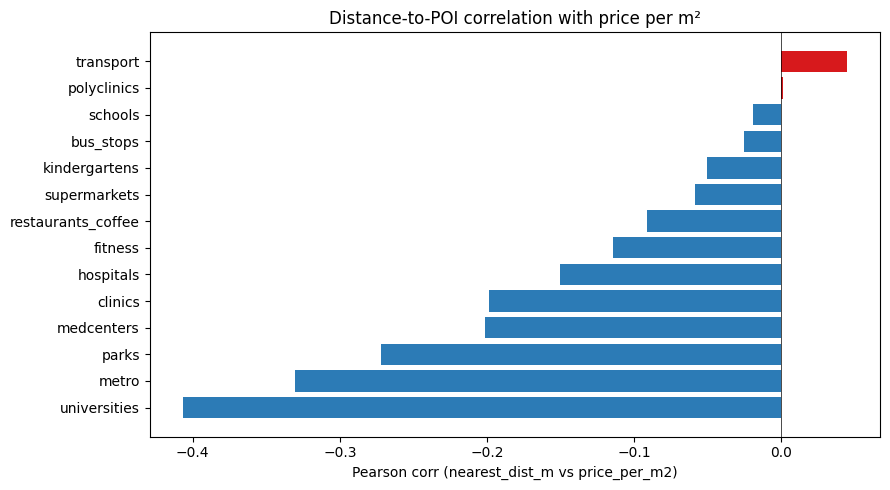

In [3]:
corr_rows = []
for cat in POI_CATEGORIES:
    col = f'{cat}_nearest_dist_m'
    if col in df.columns:
        corr_rows.append((cat, df[col].corr(df['price_per_m2'])))

corr_df = pd.DataFrame(corr_rows, columns=['category', 'corr']).sort_values('corr')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d7191c' if v > 0 else '#2c7bb6' for v in corr_df['corr']]
ax.barh(corr_df['category'], corr_df['corr'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson corr (nearest_dist_m vs price_per_m2)')
ax.set_title('Distance-to-POI correlation with price per m²')
plt.tight_layout()
plt.show()

What this shows: universities, metro, coffee and medcenters have the strongest negative correlation — the further you are, the cheaper. Bus stops show the opposite sign (positive corr): cheaper outer-ring districts have *denser* bus coverage than the centre, so 'far from a bus stop' is actually a wealth proxy. Transport hubs (railway/airport) behave the same way.

## 3. Metro proximity → price gradient

Median price/m² across bands of distance to the nearest metro station.

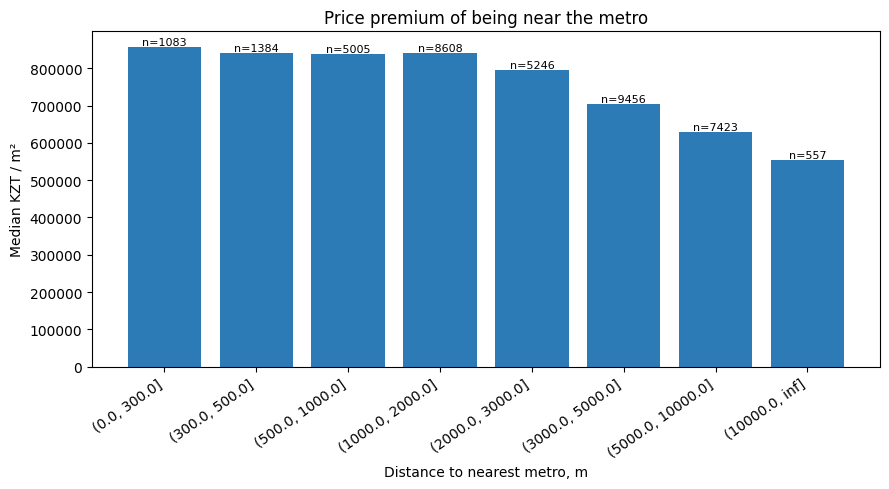

In [4]:
bins = pd.cut(df['metro_nearest_dist_m'], bins=[0, 300, 500, 1000, 2000, 3000, 5000, 10000, np.inf])
metro_band = df.groupby(bins, observed=True)['price_per_m2'].agg(['median', 'count'])
metro_band.index = metro_band.index.astype(str)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(metro_band.index, metro_band['median'], color='#2c7bb6')
ax.set_xlabel('Distance to nearest metro, m')
ax.set_ylabel('Median KZT / m²')
ax.set_title('Price premium of being near the metro')
plt.xticks(rotation=35, ha='right')
for i, (val, count) in enumerate(zip(metro_band['median'], metro_band['count'])):
    ax.text(i, val, f'n={count}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

What this shows: listings within 300 m of a metro entrance carry the largest premium, but the bin is small (only a few stations across the city). After ~5 km the curve flattens — metro proximity stops mattering once you are in the periphery, where everyone is equally far from the line.